In [22]:
import pandas as pd
import numpy as np

In [23]:
# STEP 1: PROCESS EACH NHANES CYCLE

def process_nhanes_cycle(path_dict, cycle_name):

    demo = pd.read_sas(path_dict["DEMO"])
    dpq  = pd.read_sas(path_dict["DPQ"])
    bmx  = pd.read_sas(path_dict["BMX"])
    glu  = pd.read_sas(path_dict["GLU"])
    cbc  = pd.read_sas(path_dict["CBC"])

    # --- CRP handling ---
    # FIX #4: Exclude URXCRP (urinary). Lump LBXCRP and LBXSCRP.
    #  (factor of 10).
    if "CRP" in path_dict:
        crp_df = pd.read_sas(path_dict["CRP"])
        # Prefer LBXCRP, fall back to LBXSCRP; exclude URXCRP
        if "LBXCRP" in crp_df.columns:
            crp_df["crp"] = crp_df["LBXCRP"]
        elif "LBXSCRP" in crp_df.columns:
            crp_df["crp"] = crp_df["LBXSCRP"]
        else:
            crp_df["crp"] = np.nan

    elif "BIOPRO" in path_dict:
        crp_df = pd.read_sas(path_dict["BIOPRO"])
        # LBXSCRP is standard; LBXHSCRP is high-sensitivity (divide by 10 to align units)
        if "LBXSCRP" in crp_df.columns:
            crp_df["crp"] = crp_df["LBXSCRP"]
        elif "LBXHSCRP" in crp_df.columns:
            crp_df["crp"] = crp_df["LBXHSCRP"] / 10.0  # unit conversion
        else:
            crp_df["crp"] = np.nan
    else:
        raise ValueError("Provide either 'CRP' or 'BIOPRO' in path_dict")

    df = demo.copy()
    df = df.merge(dpq,    on="SEQN", how="left")
    df = df.merge(bmx,    on="SEQN", how="left")
    df = df.merge(crp_df[["SEQN", "crp"]], on="SEQN", how="left")
    df = df.merge(glu,    on="SEQN", how="left")
    df = df.merge(cbc,    on="SEQN", how="left")

    # --- PHQ-9 columns ---
    phq_cols = ["DPQ010","DPQ020","DPQ030","DPQ040","DPQ050",
                "DPQ060","DPQ070","DPQ080","DPQ090"]
    existing_phq = [c for c in phq_cols if c in df.columns]

    # FIX #1: Replace refused values/ ONLY in PHQ-9 columns, not entire dataframe.
    # Now this is preventing accidentally zeroing out legitimate values in other columns.
    df[existing_phq] = df[existing_phq].replace([7, 77, 777, 9, 99, 999], np.nan)

    # FIX #2: Round PHQ-9 values to integers to catch float artifacts (e.g., 9.000001).
    # NHANES SAS files sometimes import as floats.
    # I round first, then keep as float (NaN-safe) -- no astype("Int64") needed
    for col in existing_phq:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].round()  # stays float but values are now 0.0, 1.0, etc.

    # FIX #3: Only compute PHQ-9 sum if ALL 9 items are present (no NaN).
    # Sum with NaN treated as 0 would undercount depression severity.
    df["phq9_complete"] = df[existing_phq].notna().all(axis=1)
    df["phq9_score"] = df[existing_phq].sum(axis=1, skipna=False)  # NaN if any missing

    n_incomplete = (~df["phq9_complete"]).sum()
    print(f"  {cycle_name}: {n_incomplete} participants with ≥1 missing PHQ-9 item (excluded)")

    df["depression_label"] = (df["phq9_score"] >= 10).astype(int)
    df["suicide_q9"] = df["DPQ090"] if "DPQ090" in df.columns else np.nan

    rename_map = {
        "RIDAGEYR": "age",
        "RIAGENDR": "sex",
        "RIDRETH1": "race",
        "DMDEDUC2": "education",
        "DMDMARTL": "marital_status",
        "INDFMPIR": "income_ratio",
        "BMXWT":   "weight",
        "BMXHT":   "height",
        "BMXBMI":  "bmi",
        "BMXWAIST":"waist",
        "BMXHIP":  "hip",
        "LBXGLU":  "glucose",
        "LBXWBCSI":"wbc",
        "LBXHGB":  "hemoglobin",
        "LBXPLTSI":"platelet"
    }
    df = df.rename(columns=rename_map)

    if "waist" in df.columns and "hip" in df.columns:
        df["waist_hip_ratio"] = df["waist"] / df["hip"]

    # FIX #7: Convert sex from 1/2 (NHANES coding) to binary 0/1
    # (1=Male->0, 2=Female->1) so it's not treated as continuous
    if "sex" in df.columns:
        df["sex"] = df["sex"].map({1: 0, 2: 1})  # 0=Male, 1=Female

    keep_cols = [
        "SEQN", "WTMEC2YR", "SDMVSTRA", "SDMVPSU",
        "age","sex","race","education","marital_status","income_ratio",
        "weight","height","bmi","waist","hip","waist_hip_ratio",
        "glucose","crp","wbc","hemoglobin","platelet",
        "phq9_score","depression_label","suicide_q9"
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols]

    protected = {"SEQN","WTMEC2YR","SDMVSTRA","SDMVPSU",
                 "phq9_score","depression_label"}
    cols_to_check = [c for c in df.columns if c not in protected]
    good_cols     = [c for c in cols_to_check if df[c].isna().mean() < 0.5]
    df = df[list(protected.intersection(df.columns)) + good_cols]

    # Drop participants with any missing PHQ-9 item (FIX #3)
    df = df.dropna(subset=["phq9_score"])

    df["cycle"] = cycle_name
    print(f"  {cycle_name} → final shape: {df.shape}")
    return df

In [24]:

# ============================================================
# STEP 2: FILE PATHS FOR ALL CYCLES
# ============================================================

paths_2005 = {"DEMO":"DEMO_D.xpt","DPQ":"DPQ_D.xpt","BMX":"BMX_D.xpt",
              "CRP":"CRP_D.xpt","GLU":"GLU_D.xpt","CBC":"CBC_D.xpt"}
paths_2007 = {"DEMO":"DEMO_E.xpt","DPQ":"DPQ_E.xpt","BMX":"BMX_E.xpt",
              "CRP":"CRP_E.xpt","GLU":"GLU_E.xpt","CBC":"CBC_E.xpt"}
paths_2009 = {"DEMO":"DEMO_F.xpt","DPQ":"DPQ_F.xpt","BMX":"BMX_F.xpt",
              "CRP":"CRP_F.xpt","GLU":"GLU_F.xpt","CBC":"CBC_F.xpt"}
paths_2011 = {"DEMO":"DEMO_G.xpt","DPQ":"DPQ_G.xpt","BMX":"BMX_G.xpt",
              "GLU":"GLU_G.xpt","CBC":"CBC_G.xpt","BIOPRO":"BIOPRO_G.xpt"}
paths_2013 = {"DEMO":"DEMO_H.xpt","DPQ":"DPQ_H.xpt","BMX":"BMX_H.xpt",
              "GLU":"GLU_H.xpt","CBC":"CBC_H.xpt","BIOPRO":"BIOPRO_H.xpt"}
paths_2015 = {"DEMO":"DEMO_I.xpt","DPQ":"DPQ_I.xpt","BMX":"BMX_I.xpt",
              "GLU":"GLU_I.xpt","CBC":"CBC_I.xpt","BIOPRO":"BIOPRO_I.xpt"}
paths_2017 = {"DEMO":"DEMO_J.xpt","DPQ":"DPQ_J.xpt","BMX":"BMX_J.xpt",
              "GLU":"GLU_J.xpt","CBC":"CBC_J.xpt","BIOPRO":"BIOPRO_J.xpt"}
paths_2019 = {"DEMO":"DEMO_P.xpt","DPQ":"DPQ_P.xpt","BMX":"BMX_P.xpt",
              "GLU":"GLU_P.xpt","CBC":"CBC_P.xpt","BIOPRO":"BIOPRO_P.xpt"}
paths_2021 = {"DEMO":"DEMO_L.xpt","DPQ":"DPQ_L.xpt","BMX":"BMX_L.xpt",
              "GLU":"GLU_L.xpt","CBC":"CBC_L.xpt","BIOPRO":"BIOPRO_L.xpt"}


In [25]:
# ============================================================
# STEP 3: PROCESS EACH CYCLE
# ============================================================

df_2005 = process_nhanes_cycle(paths_2005, "2005_2006")
df_2007 = process_nhanes_cycle(paths_2007, "2007_2008")
df_2009 = process_nhanes_cycle(paths_2009, "2009_2010")
df_2011 = process_nhanes_cycle(paths_2011, "2011_2012")
df_2013 = process_nhanes_cycle(paths_2013, "2013_2014")
df_2015 = process_nhanes_cycle(paths_2015, "2015_2016")
df_2017 = process_nhanes_cycle(paths_2017, "2017_2018")
df_2019 = process_nhanes_cycle(paths_2019, "2019_2020")
df_2021 = process_nhanes_cycle(paths_2021, "2021_2023")

  2005_2006: 5549 participants with ≥1 missing PHQ-9 item (excluded)
  2005_2006 → final shape: (4799, 20)
  2007_2008: 4734 participants with ≥1 missing PHQ-9 item (excluded)
  2007_2008 → final shape: (5415, 22)
  2009_2010: 4991 participants with ≥1 missing PHQ-9 item (excluded)
  2009_2010 → final shape: (5546, 22)
  2011_2012: 4831 participants with ≥1 missing PHQ-9 item (excluded)
  2011_2012 → final shape: (4925, 21)
  2013_2014: 4803 participants with ≥1 missing PHQ-9 item (excluded)
  2013_2014 → final shape: (5372, 21)
  2015_2016: 4837 participants with ≥1 missing PHQ-9 item (excluded)
  2015_2016 → final shape: (5134, 21)
  2017_2018: 4186 participants with ≥1 missing PHQ-9 item (excluded)
  2017_2018 → final shape: (5068, 23)
  2019_2020: 7284 participants with ≥1 missing PHQ-9 item (excluded)
  2019_2020 → final shape: (8276, 21)
  2021_2023: 6478 participants with ≥1 missing PHQ-9 item (excluded)
  2021_2023 → final shape: (5455, 21)


In [26]:
# STEP 4: COMBINE ALL CYCLES

final_df = pd.concat([
    df_2005, df_2007, df_2009, df_2011, df_2013,
    df_2015, df_2017, df_2019, df_2021
], ignore_index=True)

print("\n===== COMBINED DATASET =====")
print("Total rows:", final_df.shape[0])
print("Total columns:", final_df.shape[1])
print("\nRows per cycle:")
print(final_df["cycle"].value_counts().sort_index())


===== COMBINED DATASET =====
Total rows: 49990
Total columns: 24

Rows per cycle:
cycle
2005_2006    4799
2007_2008    5415
2009_2010    5546
2011_2012    4925
2013_2014    5372
2015_2016    5134
2017_2018    5068
2019_2020    8276
2021_2023    5455
Name: count, dtype: int64


In [27]:
# STEP 5: SURVEY WEIGHTS

n_cycles = 9
final_df["weight_adj"] = final_df["WTMEC2YR"] / n_cycles

total_n     = len(final_df)
n_depressed = final_df["depression_label"].sum()
n_not_dep   = total_n - n_depressed

print(f"\nTotal N:       {total_n}")
print(f"Depressed:     {n_depressed}  ({100*n_depressed/total_n:.1f}%)")
print(f"Not depressed: {n_not_dep}  ({100*n_not_dep/total_n:.1f}%)")

final_df["class_weight"] = final_df["depression_label"].apply(
    lambda x: total_n / (2 * n_depressed) if x == 1
              else total_n / (2 * n_not_dep)
)
final_df["combined_weight"] = final_df["weight_adj"] * final_df["class_weight"]


Total N:       49990
Depressed:     4658  (9.3%)
Not depressed: 45332  (90.7%)


In [28]:
# STEP 6: EXPORT CSV FOR R

final_df.to_csv("nhanes_combined_final.csv", index=False)
print("\nCSV exported successfully!")
print("Columns:", list(final_df.columns))



CSV exported successfully!
Columns: ['SEQN', 'SDMVPSU', 'WTMEC2YR', 'phq9_score', 'depression_label', 'SDMVSTRA', 'age', 'sex', 'race', 'marital_status', 'income_ratio', 'weight', 'height', 'bmi', 'waist', 'crp', 'wbc', 'hemoglobin', 'platelet', 'cycle', 'education', 'suicide_q9', 'hip', 'waist_hip_ratio', 'weight_adj', 'class_weight', 'combined_weight']


In [29]:
# STEP 7: PREPARE DATA FOR MODELING

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve,
                              precision_recall_curve)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

features = [col for col in [
    "age", "sex", "income_ratio", "bmi", "wbc"
] if col in final_df.columns]

print("\nFeatures used:", features)

# FIX #12: Standardize features so logistic coefficients are comparable
X_raw = final_df[features].copy()
y = final_df["depression_label"]

# FIX #6: Used stratify=y so both splits maintain the same class ratio
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y  # <-- FIX #6
)

# FIX #5: Fit scaler or imputer on TRAINING data only, then apply to test
# This prevents data leakage (test data influencing training statistics)
train_medians = X_train_raw.median()          # compute medians from train only
X_train_filled = X_train_raw.fillna(train_medians)
X_test_filled  = X_test_raw.fillna(train_medians)  # use TRAIN medians on test

# FIX #12: Standardize (mean=0, std=1) using TRAIN stats only
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train_filled),
    columns=features
)
X_test = pd.DataFrame(
    scaler.transform(X_test_filled),
    columns=features
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Features used: ['age', 'sex', 'income_ratio', 'bmi', 'wbc']

Training samples: 39992
Testing samples:  9998


In [33]:

# STEP 8: MODEL 1 — STANDARD LOGISTIC REGRESSION (baseline)

print("\n" + "="*50)
print("MODEL 1: Standard Logistic Regression (baseline)")
print("="*50)

model_std = LogisticRegression(max_iter=1000, random_state=42)
model_std.fit(X_train, y_train)
y_pred_std = model_std.predict(X_test)

print(confusion_matrix(y_test, y_pred_std))
print(classification_report(y_test, y_pred_std))

# FIX #8: Also compute AUC for the baseline model to show how poorly it performs
y_probs_std = model_std.predict_proba(X_test)[:, 1]
auc_std = roc_auc_score(y_test, y_probs_std)
print(f"AUC (standard, no balancing): {auc_std:.4f}")


MODEL 1: Standard Logistic Regression (baseline)
[[9066    0]
 [ 932    0]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      9066
           1       0.00      0.00      0.00       932

    accuracy                           0.91      9998
   macro avg       0.45      0.50      0.48      9998
weighted avg       0.82      0.91      0.86      9998

AUC (standard, no balancing): 0.6649


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:

# STEP 9: MODEL 2 — BALANCED LOGISTIC REGRESSION (main model)

print("\n" + "="*50)
print("MODEL 2: Balanced Logistic Regression (main model)")
print("="*50)

model_bal = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
model_bal.fit(X_train, y_train)
y_pred_bal = model_bal.predict(X_test)

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

y_probs_bal = model_bal.predict_proba(X_test)[:, 1]
auc_bal = roc_auc_score(y_test, y_probs_bal)
print(f"AUC: {auc_bal:.4f}")


MODEL 2: Balanced Logistic Regression (main model)
[[5278 3788]
 [ 309  623]]
              precision    recall  f1-score   support

           0       0.94      0.58      0.72      9066
           1       0.14      0.67      0.23       932

    accuracy                           0.59      9998
   macro avg       0.54      0.63      0.48      9998
weighted avg       0.87      0.59      0.67      9998

AUC: 0.6670


In [36]:
# STEP 10: MODEL 3 — RANDOM FOREST WITH SMOTE ONLY
# FIX #9: use SMOTE OR class_weight, not both

print("\n" + "="*50)
print("MODEL 3: Random Forest + SMOTE (no class_weight)")
print("="*50)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — training samples: {len(X_train_sm)}")
print(f"Depressed in training: {y_train_sm.sum()}")

rf = RandomForestClassifier(
    n_estimators=200,
    # FIX #9: Removed class_weight="balanced" — SMOTE is already handling imbalance
    random_state=42
)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_probs_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_probs_rf)
print(f"AUC: {auc_rf:.4f}")


MODEL 3: Random Forest + SMOTE (no class_weight)
After SMOTE — training samples: 72532
Depressed in training: 36266
[[8326  740]
 [ 626  306]]
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      9066
           1       0.29      0.33      0.31       932

    accuracy                           0.86      9998
   macro avg       0.61      0.62      0.62      9998
weighted avg       0.87      0.86      0.87      9998

AUC: 0.7221


In [37]:
# STEP 11: MODEL 3B — RANDOM FOREST WITH LOWER THRESHOLD

print("\n" + "="*50)
print("MODEL 3B: Random Forest + SMOTE + threshold 0.3")
print("="*50)

y_pred_rf_t = (y_probs_rf > 0.3).astype(int)
print(confusion_matrix(y_test, y_pred_rf_t))
print(classification_report(y_test, y_pred_rf_t))


MODEL 3B: Random Forest + SMOTE + threshold 0.3
[[6819 2247]
 [ 422  510]]
              precision    recall  f1-score   support

           0       0.94      0.75      0.84      9066
           1       0.18      0.55      0.28       932

    accuracy                           0.73      9998
   macro avg       0.56      0.65      0.56      9998
weighted avg       0.87      0.73      0.78      9998



In [38]:

# STEP 12: PHQ-9 REGRESSION MODEL

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("\n" + "="*50)
print("MODEL 4: PHQ-9 Score Regression")
print("="*50)

# FIX #5 applied here too -- use train medians for imputation
X_reg_train = X_train_filled.copy()
X_reg_test  = X_test_filled.copy()
y_reg_train = final_df.loc[X_train_raw.index, "phq9_score"]
y_reg_test  = final_df.loc[X_test_raw.index,  "phq9_score"]

reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)
y_pred_r = reg_model.predict(X_reg_test)

print(f"MAE:  {mean_absolute_error(y_reg_test, y_pred_r):.4f}")
print(f"R2:   {r2_score(y_reg_test, y_pred_r):.4f}")


MODEL 4: PHQ-9 Score Regression
MAE:  3.1024
R2:   0.0526


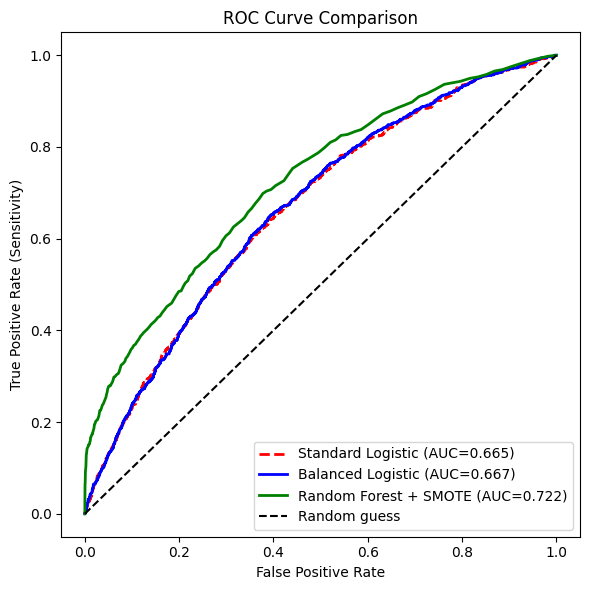

In [39]:
# STEP 13: ROC CURVE — ALL 3 MODELS

fpr_std, tpr_std, _ = roc_curve(y_test, y_probs_std)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_probs_bal)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_probs_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_std, tpr_std,
         label=f"Standard Logistic (AUC={auc_std:.3f})",
         color="red", lw=2, linestyle="--")
plt.plot(fpr_bal, tpr_bal,
         label=f"Balanced Logistic (AUC={auc_bal:.3f})",
         color="blue", lw=2)
plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest + SMOTE (AUC={auc_rf:.3f})",
         color="green", lw=2)
plt.plot([0,1], [0,1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=300)   # FIX #10
plt.show()

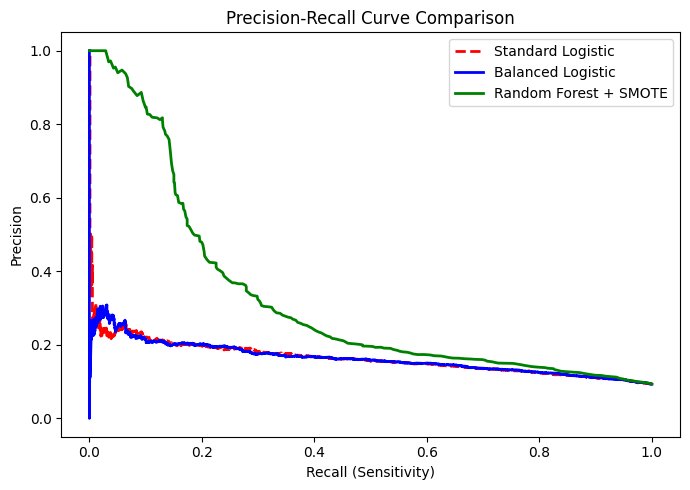

In [40]:
# STEP 14: PRECISION-RECALL CURVE
# FIX #11: Include in output — more informative for imbalanced data

prec_std, rec_std, _ = precision_recall_curve(y_test, y_probs_std)
prec_bal, rec_bal, _ = precision_recall_curve(y_test, y_probs_bal)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, y_probs_rf)

plt.figure(figsize=(7, 5))
plt.plot(rec_std, prec_std, color="red",   lw=2, linestyle="--",
         label="Standard Logistic")
plt.plot(rec_bal, prec_bal, color="blue",  lw=2, label="Balanced Logistic")
plt.plot(rec_rf,  prec_rf,  color="green", lw=2, label="Random Forest + SMOTE")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_curve.png", dpi=300)   # FIX #10
plt.show()


--- Balanced Logistic Regression Coefficients (Standardized) ---
sex             0.226231
bmi             0.190432
wbc             0.165645
age            -0.019568
income_ratio   -0.502235
dtype: float64

--- Random Forest Feature Importance ---
age             0.259688
income_ratio    0.246138
wbc             0.241297
bmi             0.236095
sex             0.016783
dtype: float64


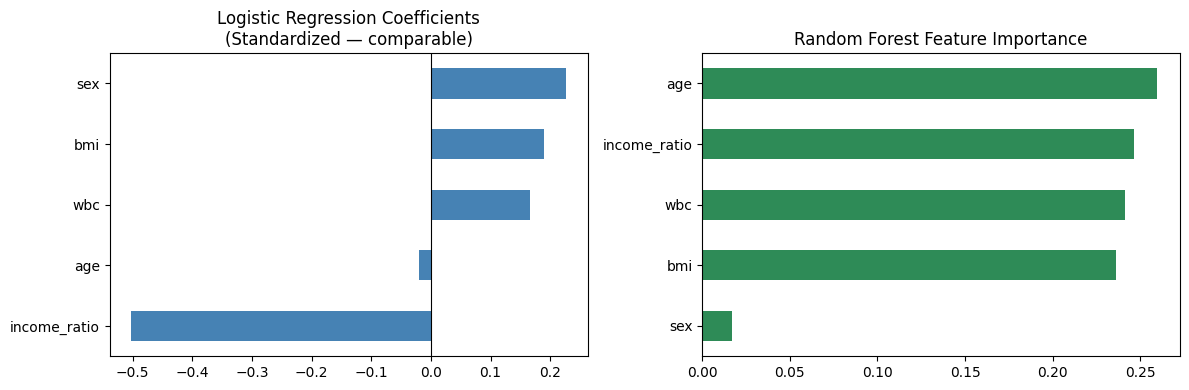

In [41]:
# STEP 15: FEATURE IMPORTANCE
# FIX #12: Now coefficients are standardized -> directly comparable

print("\n--- Balanced Logistic Regression Coefficients (Standardized) ---")
coef_series = pd.Series(model_bal.coef_[0], index=features)
print(coef_series.sort_values(ascending=False))

print("\n--- Random Forest Feature Importance ---")
importance_series = pd.Series(rf.feature_importances_, index=features)
print(importance_series.sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

coef_series.sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue"
)
axes[0].set_title("Logistic Regression Coefficients\n(Standardized — comparable)")
axes[0].axvline(0, color="black", lw=0.8)

importance_series.sort_values().plot(
    kind="barh", ax=axes[1], color="seagreen"
)
axes[1].set_title("Random Forest Feature Importance")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)   # FIX #10
plt.show()

In [42]:
# STEP 16: FINAL SUMMARY TABLE

print("\n" + "="*60)
print("           FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<38} {'AUC':>6}  {'Note'}")
print("-"*60)
print(f"{'Standard Logistic (no balancing)':<38} {auc_std:>6.3f}  Baseline — recall≈0")
print(f"{'Balanced Logistic':<38} {auc_bal:>6.3f}  Best recall")
print(f"{'Random Forest + SMOTE':<38} {auc_rf:>6.3f}  Best AUC")
print(f"{'PHQ-9 Regression (MAE)':<38} {'—':>6}  Score prediction")
print("="*60)
print("\nNote: Final survey-weighted model → run in R with svyglm()")


           FINAL MODEL COMPARISON SUMMARY
Model                                     AUC  Note
------------------------------------------------------------
Standard Logistic (no balancing)        0.665  Baseline — recall≈0
Balanced Logistic                       0.667  Best recall
Random Forest + SMOTE                   0.722  Best AUC
PHQ-9 Regression (MAE)                      —  Score prediction

Note: Final survey-weighted model → run in R with svyglm()
